# initialisation and code inclusion

## packages

In [3]:
using Sobol
using NLsolve
using QuadGK
using Integrals
using FiniteDiff
using StaticArrays
using Contour
using Peaks

In [4]:
using GLMakie

In [5]:
using GeometryBasics

In [6]:
### Required for triangles downward flow
using StaticArrays
using LinearAlgebra

## PL methods

In [7]:
### specify where you have the PL code. Possibly that's in the PicardLefschetz.jl!!!!
pathtoPL = "../../HHGsimPL.jl-user/src/header/PLIntegration2D/"; 

In [8]:
include(pathtoPL*"utils.jl")

In [9]:
include(pathtoPL*"flow-utils.jl");

## HHG

In [10]:
pathtoHHG="../../HHGsimPL.jl-user/src/header/"; # this wants to work on the "user" branch of that git repo

In [11]:
include(pathtoHHG*"includes.jl")

# plotting functions

In [12]:
include("src/plotting-utilities.jl");

In [13]:
scr1 = GLMakie.Screen();

In [14]:
scr2 = GLMakie.Screen();

## 2d projections

In [15]:
function get_mesh_2d(quads::Vector{QuadC}, coords::Function)
    ### TODO this makes the mesh out of triangles (which can be misleading if you want to compare to the actual triangle grid)
    vertices = reduce(vcat,[
        [Point2f(coords(p)) for p in quad.points ]
        for quad in quads  ])
    faces = [QuadFace(i, i+1, i+2, i+3) for i in 1:4:length(vertices)]
        
    return normal_mesh(vertices, faces)
end

get_mesh_2d (generic function with 1 method)

## 3d projections

In [16]:
function get_mesh_3d(quads::Vector{QuadC}, coords::Function)
    vertices = reduce(vcat,[
        [Point3f(coords(p)) for p in quad.points ]
        for quad in quads  ])
    faces = [QuadFace(i, i+1, i+2, i+3) for i in 1:4:length(vertices)]
        
    return normal_mesh(vertices, faces)
end;

In [17]:
function plot_individual_quads!(ax, simplices::Vector{QuadC}, coords::Function)
    ### because if you plot a list of QuadC as a mesh, then it automatically makes triangles from it. But maybe you want to plot them as actual quads, so we generate a mesh for each quad and plot it (so it ends up in the same colour)
    for quad in simplices
        m_q = get_mesh_3d([quad], coords)
        mesh!(ax, m_q)
        linesegments!(ax, m_q.vertex_attributes[1][[1,2,2,3,3,4,4,1]])
    end
end

plot_individual_quads! (generic function with 1 method)

In [18]:
function get_mesh_3d(tris::Vector{TriangleC}, coords::Function)
    vertices = reduce(vcat,[
        [Point3f(coords(p)) for p in tri.points ]
        for tri in tris  ])
    faces = [TriangleFace(i, i+1, i+2) for i in 1:3:length(vertices)]
        
    return normal_mesh(vertices, faces)
end;

In [19]:
function plot_individual_triangles!(ax, simplices::Vector{TriangleC}, coords::Function)
    for tri in simplices
        m_q = get_mesh_3d([tri], coords)
        mesh!(ax, m_q)
        linesegments!(ax, m_q.vertex_attributes[1][[1,2,2,3,3,1]])
    end
end

plot_individual_triangles! (generic function with 1 method)

# hhg setup

In [20]:
### Ankas setup
const Ip = IpAU(15.7596) # Argon gas target
const λ = 1030 #wavelength in nm
r = 1 # ω
s = 2 # 2*ω
const ε = 0.0 # linearly polarised field
const I_total = 0.92e14;
TC = TCycle(lambda= λ);

In [21]:
beam_mono = let
    R = 0.
    ϕ = 0.
    beam = BeamBETC(Intensity1 = I_total, 
    Intensity2 = R/(1-R)*I_total,
    lambda=λ,r=1,s=2,epsilon=ε,
    phi = ϕ)
    
    beam
end

BeamTC(0.05126959555693246, 0.0, 0.04422487690455352, 0.08844975380910704, 0.0, 0.0, 0.0)

## briefly check the necklace and whether saddle points are relevant

In [22]:
include(pathtoPL*"necklace-for-dual-thimble.jl");

In [23]:
include(pathtoPL*"saddles-contributing.jl");

In [24]:
### using the HHG-defined functions
let
    vec = Vector{Tuple}()
    beam = beam_mono
    ti_domain = ComplexDomain(0., 1., 0.01,0.3)*TC;
    tr_domain = ComplexDomain(0.1,2., -0.3,0.3)*TC;   
    q = 25.
    saddles = filter(s -> 10 < real(s.tr - s.ti) < 1*TC,
        find_saddles_sobol(q, b=beam, Ip = Ip,
        ti_cd = ti_domain, tr_cd = tr_domain, N = 300) )
    for ts in saddles
        @show ts
        @show traveltime(ts)
        relevant = check_contribution(beam, Ip, q, ts.ti, ts.tr)
        @show relevant    
        println()
    end
end

ts = ti: 37.7 + 18.88im, tr: 158.3 + 0.1im, q25.0
traveltime(ts) = 120.60000000000001 - 18.779999999999998im
relevant = true

ts = ti: 48.09 + 23.59im, tr: 107.52 - 2.88im, q25.0
traveltime(ts) = 59.42999999999999 - 26.47im
relevant = true

ts = ti: 51.59 + 26.42im, tr: 73.23 - 30.36im, q25.0
traveltime(ts) = 21.64 - 56.78im
relevant = false

ts = ti: 108.73 + 18.88im, tr: 229.34 + 0.1im, q25.0
traveltime(ts) = 120.61 - 18.779999999999998im
relevant = true

ts = ti: 119.13 + 23.59im, tr: 178.56 - 2.88im, q25.0
traveltime(ts) = 59.43000000000001 - 26.47im
relevant = true



In [242]:
?check_contribution ### to see where you have definitions of this function from

search: check_contribution help_attributes



No documentation found for private binding `Main.check_contribution`.

`check_contribution` is a `Function`.

```
# 5 methods for generic function "check_contribution" from Main:
 [1] check_contribution(f::Function, f_grad::Function, f_hessian::Function, ti::ComplexF64, tr::ComplexF64; Ntimes, logerrors, kwargs...)
     @ ~/OneDrive/HHGsimPL.jl-user/src/header/PLIntegration2D/saddles-contributing.jl:164
 [2] check_contribution(necklace::Nothing, f::Function, ti::ComplexF64, tr::ComplexF64; Ntimes, kwargs...)
     @ ~/OneDrive/HHGsimPL.jl-user/src/header/PLIntegration2D/saddles-contributing.jl:156
 [3] check_contribution(necklace::Nothing, f::Function, f_grad::Function, f_hessian::Function, ti::ComplexF64, tr::ComplexF64; Ntimes, kwargs...)
     @ ~/OneDrive/HHGsimPL.jl-user/src/header/PLIntegration2D/saddles-contributing.jl:147
 [4] check_contribution(necklace::Vector{LineSeg}, f::Function, ti::ComplexF64, tr::ComplexF64; Ntimes, kwargs...)
     @ ~/OneDrive/HHGsimPL.jl-user/src/header/PLIntegration2D/saddles-contributing.jl:109
 [5] check_contribution(beam::Beam, Ip::Float64, q::Number, ti::ComplexF64, tr::ComplexF64; Ntimes, logerrors, kwargs...)
     @ ~/OneDrive/HHGsimPL.jl-user/src/header/saddles.jl:167
```


# thimbles around given saddle point [!!!! THE INTEGRATION DOESN'T WORK YET THOUGH!!!]

## define two test saddle points

In [25]:
### using the HHG-defined functions
ts1, ts2 = let
    vec = Vector{Tuple}()
    beam = beam_mono
    ti_domain = ComplexDomain(0., 1., 0.01,0.3)*TC;
    tr_domain = ComplexDomain(0.1,2., -0.3,0.3)*TC;   
    q = 25.
    saddles = filter(s -> 10 < real(s.tr - s.ti) < 1*TC,
        find_saddles_sobol(q, b=beam, Ip = Ip,
        ti_cd = ti_domain, tr_cd = tr_domain, N = 300) )
    saddles[[1,2]]
end

2-element Vector{Saddle}:
 ti: 37.7 + 18.88im, tr: 158.3 + 0.1im, q25.0
 ti: 48.09 + 23.59im, tr: 107.52 - 2.88im, q25.0

## quadrilaterals

In [36]:
include(pathtoPL*"thimble-from-saddle-point-quadrilaterals.jl");
include(pathtoPL*"integrate-quads.jl");

In [27]:
include(pathtoPL*"saddle-point-method.jl");

### get and integrate quadrilaterals

In [38]:
let
    beam = beam_mono
    ts = ts1
    q = 25.
    f, f_grad, f_hessian = action_functions(beam, Ip, q)
    
    quads = get_SD_thimble_quads(f, f_grad, f_hessian, ts.ti, ts.tr,
        flowstepfactor = 5.,
        Ncounter = 5,
        eigvecfactorinit=0.05,
        subdividethreshold = 8.
        )
    
    
    int = zeros(ComplexF64,2)
    
    for quad in quads
        int_q = integrate_quadrilateral(f, quad, 
            prefactor=(ti, tr)-> hhg_prefactor(beam, Ip, ti, tr))
        int .+= int_q
    end
   @show int
   sign_ns = intersection_number_sign_cheat(int, f, f_hessian, ts.ti, ts.tr)
    @show sign_ns
end;

I broke because the counter reached its max, i.e. 5
int = ComplexF64[-8.033075223243276e-6 - 8.949226312279758e-6im, 0.0 + 0.0im]
sign_ns = 1.0


### plot quadrilaterals in 2d

In [27]:
let
    scr= scr1
    beam = beam_mono
    ts = ts1
    q = 25.
    
    simplices = get_SD_thimble_quads(action_functions(beam, Ip, q)..., ts.ti, ts.tr)
    @show length(simplices)
    f = Figure()
    
    ax = [
        Axis(f[1,1], title = "proj 1", xlabel="Re(x)", ylabel="Im(x)"),
        Axis(f[1,2], title = "proj 2", xlabel="Re(y)", ylabel="Im(y)"),
        Axis(f[2,1], title = "proj 3", xlabel="Re(x)", ylabel="Re(y)"),
        Axis(f[2,2], title = "proj 4", xlabel="Im(x)", ylabel="Im(y)")
        ]
    
# #     j = Int(ceil(length(points)/7))

    color = :blue
    for proj in 1:4

        m_1 = get_mesh_2d(simplices[1:150], coords_2d[proj])
        mesh!(ax[proj], m_1, color=color)
        wireframe!(ax[proj], m_1, color=color)
        
        scatter!(ax[proj], coords_2d[proj](PointA(ts.ti, ts.tr)), color=:black, markersize = 10)
    end       

    display(scr, f)
end

length(simplices) = 195


GLMakie.Screen(...)

### plot quadrilaterals in 3d

In [98]:
let
    beam = beam_mono
    ts = ts1
    q = 25.
    
    simplices = get_SD_thimble_quads(
        action_functions(beam, Ip, q)..., ts.ti, ts.tr,
        flowstepfactor = 5.,
        Ncounter = 5,
        eigvecfactorinit=0.5,
        subdividethreshold = 8.
        )
    
    @show length(simplices)
    plot_simplices = simplices # thimbles_shorts_quads[10] # simplices
    
    plot_points = unique(vcat([sim.points for sim in plot_simplices]...))
    
    fig = Figure()
    ax_1 = LScene(fig[1, 1])
    initialise_axes!(ax_1, (0,80), (100, 180), (0,50))  
    ax_2 = LScene(fig[1,2])
    initialise_axes!(ax_2, (180,250), (0,80), (-50,50))
    
#     scatter!(ax_1, [coords_3d[1](p) for p in plot_points], color=:red)    
    
    color = :blue
     
    plot_individual_quads!(ax_1, plot_simplices, coords_3d[1])
    plot_individual_quads!(ax_2, plot_simplices, coords_3d[2])
    
    ### alternatively (if you want the whole mesh in one colour, but meshed into triangles)
#     m_2 = get_mesh_3d(plot_simplices, coords_3d[2])
#     mesh!(ax_2, m_2, color=color)
#     wireframe!(ax_2, m_2, color=color)    

    
#     scatter!(ax_2, [coords_3d[2](p) for p in plot_points], color=:red)    
    
    scatter!(ax_1, coords_3d[1](PointA(ts.ti, ts.tr)), color=:black, markersize = 10)
    scatter!(ax_2, coords_3d[2](PointA(ts.ti, ts.tr)), color=:black, markersize = 10)
    
    display(scr2, fig)    
    
end    

I broke because the counter reached its max, i.e. 5
length(simplices) = 109


GLMakie.Screen(...)

## triangles

In [39]:
include(pathtoPL*"downward-flow-triangles.jl");
include(pathtoPL*"thimble-from-saddle-point-triangles.jl");
include(pathtoPL*"integrate-triangles.jl");

### get and integrate the thimble

In [41]:
let 
    beam = beam_mono
    ts = ts1
    q = 25.
    f, f_grad, f_hessian = action_functions(beam, Ip, q)
    
   triangles, points, indices = get_SD_thimble_triangles(
        f, f_grad, f_hessian, ts.ti, ts.tr,
        Nflow = 5,
        flowstepfactor = 5.,
        eigvecfactorinit=0.05,
        gradn_threshold = 0.021,
        subdividethreshold = 8.
        )
        

    prefactor=(ti, tr)-> hhg_prefactor(beam, Ip, ti, tr)
    int = zeros(ComplexF64,2)
    
    for tri in triangles
        int_t = integrate_triangle_cheat(f, tri, prefactor=prefactor) # for now this seems to work better
        int .+= int_t
    end
    sign_ns = intersection_number_sign_cheat(int, f, f_hessian, ts.ti, ts.tr)
    @show sign_ns
    int
end

threshold = 0.00041
sign_ns = -1.0


2-element Vector{ComplexF64}:
 7.508394728866696e-9 + 7.883416177112085e-9im
                  0.0 + 0.0im

### plotting in 3d

In [241]:
let
    beam = beam_mono
    ts = ts1
    q = 25.
    
   simplices, _, _ = get_SD_thimble_triangles(
        action_functions(beam, Ip, q)..., ts.ti, ts.tr,
        Nflow = 5,
        flowstepfactor = 5.,
        eigvecfactorinit=0.5,
        gradn_threshold = 0.021,
        subdividethreshold = 8.
        )
#     @show length(simplices)
    plot_simplices = simplices
#     plot_simplices = full_thimble_triangles[10] ### you might want to plot some of the calculated stuff from somewhere below
        
    plot_points = unique(vcat([sim.points for sim in plot_simplices]...))

    fig = Figure()
    ax_1 = LScene(fig[1, 1])
    initialise_axes!(ax_1, (0,80), (100, 180), (0,50))  ### these are the axes limits
    ax_2 = LScene(fig[1,2])
    initialise_axes!(ax_2, (180,250), (0,80), (-50,50))
    
#     scatter!(ax_1, [coords_3d[1](p) for p in plot_points], color=:red)    
       
#     plot_individual_triangles!(ax_1, plot_simplices, coords_3d[1])
#     plot_individual_triangles!(ax_2, plot_simplices, coords_3d[2])

     ### alternatively (if you want the whole mesh in one colour, but meshed into triangles)
    m_1 = get_mesh_3d(plot_simplices, coords_3d[1])
    mesh!(ax_1, m_1)
    wireframe!(ax_1, m_1)  
    
    m_2 = get_mesh_3d(plot_simplices, coords_3d[2])
    mesh!(ax_2, m_2)
    wireframe!(ax_2, m_2)    

    
#     scatter!(ax_2, [coords_3d[2](p) for p in plot_points], color=:red)    
    
    scatter!(ax_1, coords_3d[1](PointA(ts.ti, ts.tr)), color=:black, markersize = 10)
    scatter!(ax_2, coords_3d[2](PointA(ts.ti, ts.tr)), color=:black, markersize = 10)
    display(scr1, fig)
    
end    

threshold = 0.00041


GLMakie.Screen(...)

## Gaussian approximation

In [60]:
let
    beam = beam_mono
    ts = ts1
    q = 25.
    
    @show dipole(beam, Ip, ts)
end

dipole(beam, Ip, ts) = ComplexF64[-8.32388117221083e-6 - 8.735749506207966e-6im, 0.0 - 0.0im]


2-element Vector{ComplexF64}:
 -8.32388117221083e-6 - 8.735749506207966e-6im
                  0.0 - 0.0im

# downward flow

## quadrilaterals

In [51]:
include(pathtoPL*"downward-flow-quadrilaterals.jl");

### getting all the quads

In [96]:
test_quads = let
    beam = beam_mono
    q = 20.
    
    timin, timax = (0., 1.) .* TC
    ttmin, ttmax = (0.2, 1.) .* TC

    f, f_grad, f_hessian = action_functions(beam, Ip, q)
    init_points = make_init_points_parallelogram(timin, timax, ttmin, ttmax)
    
#     @show typeof(init_points)
    quads, points, indices = get_flowed_quads(f, f_grad, init_points,
        Nflow=25,
        flowstepfactor = 3.,
        subdividethreshold=10.,
        )
    @show length(quads)
    quads
end;

I converged w.r.t. number of simplices at i_flow = 23.
length(quads) = 1616


### plotting it in 3d

In [74]:
let
    scr = scr2
#     @show length(quads)
#     any([simplices])
    plot_simplices = test_quads #quads # simplices
    
    plot_points = unique(vcat([sim.points for sim in plot_simplices]...))
    
#     polys1 = [to_polygon(sim) for sim in simplices[1:20]]
    fig = Figure()
    ax_1 = LScene(fig[1, 1])
    initialise_axes!(ax_1, (0,150), (100, 250), (0,50))  
    ax_2 = LScene(fig[1,2])
    initialise_axes!(ax_2, (100,250), (0,180), (-50,50))
    
#     scatter!(ax_1, [coords_3d[1](p) for p in plot_points], color=:red)    
    
    color = :blue
    
    plot_individual_quads!(ax_1, plot_simplices, coords_3d[1])
    
#     m_1 = get_mesh_3d(plot_simplices, coords_3d[1])
#     mesh!(ax_1, m_1)
#     wireframe!(ax_1, m_1)    
    
    
    m_2 = get_mesh_3d(plot_simplices, coords_3d[2])
    mesh!(ax_2, m_2, color=color)
    wireframe!(ax_2, m_2, color=color)    

    
#     scatter!(ax_2, [coords_3d[2](p) for p in plot_points], color=:red)    
    
#     scatter!(ax_1, coords_3d[1](PointA(ts.ti, ts.tr)), color=:black, markersize = 10)
#     scatter!(ax_2, coords_3d[2](PointA(ts.ti, ts.tr)), color=:black, markersize = 10)
    display(scr, fig)    
    
end

GLMakie.Screen(...)

### integrate the flowed domain

In [97]:
let
    quads = test_quads
    beam = beam_mono
    q=20.
    
    f, f_grad, f_hessian = action_functions(beam, Ip, q)
    
    phase = (ti,tr) -> -1im*S(beam, Ip, ti, tr, q)
    int = zeros(ComplexF64,2)
    
    for quad in quads
        int_q = integrate_quadrilateral(phase, quad, 
            prefactor=(ti, tr)-> hhg_prefactor(beam, Ip, ti, tr))
        int .+= int_q
    end
   @show int
end

int = ComplexF64[-3.3750447853322486e-8 + 1.3156924582090027e-8im, 0.0 + 0.0im]


2-element Vector{ComplexF64}:
 -3.3750447853322486e-8 + 1.3156924582090027e-8im
                    0.0 + 0.0im

## triangles

In [54]:
include(pathtoPL*"downward-flow-triangles.jl");

### get test triangles

In [94]:
test_triangles = let
    beam = beam_mono
    q = 20.
    
    timin, timax = (0., 1.) .* TC
    ttmin, ttmax = (0.2, 1.) .* TC

    f, f_grad, f_hessian = action_functions(beam, Ip, q)
    init_points = make_init_points_parallelogram(timin, timax, ttmin, ttmax)
      
    triangles, _, _ = get_flowed_triangles(f, f_grad, init_points,
        Nflow=20,
        flowstepfactor = 3.,
        subdividethreshold=8.,
        )
    triangles
end;

I stopped because I reached the maximum flow steps, i.e. 20.


### plotting in 3d

In [84]:
let
    scr = scr2
    plot_simplices = test_triangles #triangles # simplices
    
    plot_points = unique(vcat([sim.points for sim in plot_simplices]...))
    
#     polys1 = [to_polygon(sim) for sim in simplices[1:20]]
    fig = Figure()
    ax_1 = LScene(fig[1, 1])
    initialise_axes!(ax_1, (0,150), (100, 250), (0,50))  
    ax_2 = LScene(fig[1,2])
    initialise_axes!(ax_2, (100,250), (0,180), (-50,50))
    
#     scatter!(ax_1, [coords_3d[1](p) for p in plot_points], color=:red)    
    m_1 = get_mesh_3d(plot_simplices, coords_3d[1])
    mesh!(ax_1, m_1)
    wireframe!(ax_1, m_1)  
    
    

    m_2 = get_mesh_3d(plot_simplices, coords_3d[2])
    mesh!(ax_2, m_2)
    wireframe!(ax_2, m_2)    

    
#     scatter!(ax_2, [coords_3d[2](p) for p in plot_points], color=:red)    
    
#     scatter!(ax_1, coords_3d[1](PointA(ts.ti, ts.tr)), color=:black, markersize = 10)
#     scatter!(ax_2, coords_3d[2](PointA(ts.ti, ts.tr)), color=:black, markersize = 10)
    display(scr, fig)    
    
end

GLMakie.Screen(...)

### integrating

In [95]:
let
    triangles = test_triangles
    beam = beam_mono
    q = 20.
    
    f, f_grad, f_hessian = action_functions(beam, Ip, q)
    
    phase = (ti,tr) -> -1im*S(beam, Ip, ti, tr, q)
    int = zeros(ComplexF64,2)
    
    for triangle in triangles
        int_q = integrate_triangle(phase, triangle, 
            prefactor=(ti, tr)-> hhg_prefactor(beam, Ip, ti, tr))
        int .+= int_q
    end
   @show int
end

int = ComplexF64[-1.0018602044791684e-6 + 3.2829070932152774e-7im, 0.0 + 0.0im]


2-element Vector{ComplexF64}:
 -1.0018602044791684e-6 + 3.2829070932152774e-7im
                    0.0 + 0.0im

## Gaussian approximation

In [43]:
### using the HHG-defined functions
let
    vec = Vector{Tuple}()
    beam = beam_mono
    ti_domain = ComplexDomain(0., 1., 0.01,0.3)*TC;
    tr_domain = ComplexDomain(0.1,2., -0.3,0.3)*TC;   
    q = 25.
    saddles = filter(s -> 10 < real(s.tr - s.ti) < 1*TC,
        find_saddles_sobol(q, b=beam, Ip = Ip,
        ti_cd = ti_domain, tr_cd = tr_domain, N = 300) )
    
    int = zeros(ComplexF64,2)

    for ts in saddles
        @show ts
#         @show traveltime(ts)
        relevant = check_contribution(beam, Ip, q, ts.ti, ts.tr)
        @show relevant    
#         println()
        if relevant
            int .+= dipole(beam, Ip, ts)
        end
    end
    @show int
#     saddles[[1,2]]
end

ts = ti: 37.7 + 18.88im, tr: 158.3 + 0.1im, q25.0
relevant = true
ts = ti: 48.09 + 23.59im, tr: 107.52 - 2.88im, q25.0
relevant = true
ts = ti: 51.59 + 26.42im, tr: 73.23 - 30.36im, q25.0
relevant = false
ts = ti: 108.73 + 18.88im, tr: 229.34 + 0.1im, q25.0
relevant = true
ts = ti: 119.13 + 23.59im, tr: 178.56 - 2.88im, q25.0
relevant = true
int = ComplexF64[-7.590782827755441e-6 - 1.78142861669464e-5im, 0.0 + 0.0im]


2-element Vector{ComplexF64}:
 -7.590782827755441e-6 - 1.78142861669464e-5im
                   0.0 + 0.0im

In [113]:
### using the HHG-defined functions
let
    vec = Vector{Tuple}()
    beam = beam_mono
    ti_domain = ComplexDomain(0., 1., 0.01,0.3)*TC;
    tr_domain = ComplexDomain(0.1,2., -0.3,0.3)*TC;   
    q = 26.
    saddles = filter(s -> 10 < real(s.tr - s.ti) < 1*TC,
        find_saddles_sobol(q, b=beam, Ip = Ip,
        ti_cd = ti_domain, tr_cd = tr_domain, N = 300) )
    
    int = zeros(ComplexF64,2)

    for ts in saddles
        @show ts
#         @show traveltime(ts)
        relevant = check_contribution(beam, Ip, q, ts.ti, ts.tr)
        @show relevant    
#         println()
        if relevant
            int .+= dipole(beam, Ip, ts)
        end
    end
    @show int
#     saddles[[1,2]]
end

ts = ti: 37.82 + 18.9im, tr: 157.29 + 0.11im, q26.0
relevant = true
ts = ti: 47.88 + 23.37im, tr: 108.77 - 2.72im, q26.0
relevant = true
ts = ti: 51.73 + 26.43im, tr: 73.1 - 30.92im, q26.0
relevant = false
ts = ti: 108.86 + 18.9im, tr: 228.32 + 0.11im, q26.0
relevant = true
ts = ti: 118.92 + 23.37im, tr: 179.81 - 2.72im, q26.0
relevant = true
int = ComplexF64[-3.1261533409632895e-9 - 2.3076649490688872e-9im, 0.0 + 0.0im]


2-element Vector{ComplexF64}:
 -3.1261533409632895e-9 - 2.3076649490688872e-9im
                    0.0 + 0.0im

# comparing calculations throughout the entire spectrum

In [42]:
q_values = collect(range(22., stop = 50., step = 0.5));

## get saddle points, and their Gaussians, and their total

In [44]:
relevant_saddles, dipoles_SPM = let
    beam = beam_mono
    ti_domain = ComplexDomain(0., 1., 0.01,0.3)*TC;
    tr_domain = ComplexDomain(0.1,2., -0.3,0.3)*TC;   
    
    dips = Vector()
    saddles_all = Vector()
    
    for q in q_values
        vec = Vector{Tuple}()
        saddles = filter(s -> 10 < real(s.tr - s.ti) < 1*TC,
            find_saddles_sobol(q, b=beam, Ip = Ip,
            ti_cd = ti_domain, tr_cd = tr_domain, N = 300) )
        
        ### only keep the relevant saddle points
        filter!(ts -> check_contribution(beam, Ip, q, ts.ti, ts.tr), saddles)
        
        push!(saddles_all, saddles)
        push!(dips, [dipole(beam, Ip, ts) for ts in saddles])
    end
    saddles_all, dips
end;

In [237]:
#### each element of this vector contains a list of dipoles (one from each relevant saddle point)
dipoles_SPM[1] 

4-element Vector{Vector{ComplexF64}}:
 [-1.7476205402783117e-7 + 1.3472187921957706e-5im, 0.0 + 0.0im]
 [7.840845055108964e-7 - 3.7156484030907308e-6im, 0.0 - 0.0im]
 [1.6955118752675168e-7 - 1.3473100303777368e-5im, 0.0 + 0.0im]
 [-7.848742732094006e-7 + 3.714971149396294e-6im, 0.0 - 0.0im]

In [104]:
### for a given harmonic we just total these dipoles
sum(dipoles_SPM[1]) 

2-element Vector{ComplexF64}:
 -6.000634199583618e-9 - 1.5896355140980736e-9im
                   0.0 + 0.0im

In [45]:
total_dipoles_SPM = [sum(q_dips) for q_dips in dipoles_SPM];

## get SD thimbles attached to the saddle points, and the total dipoles

### quadrilaterals

In [82]:
dipoles_quadrilaterals = let
    vec=Vector()
    beam = beam_mono
    for (i,q) in enumerate(q_values)
        saddles = relevant_saddles[i]
        dips = Vector()
        for ts in saddles
            f, f_grad, f_hessian = action_functions(beam, Ip, q)
            quads = get_SD_thimble_quads(f, f_grad, f_hessian, ts.ti, ts.tr,
                flowstepfactor = 5.,
                Ncounter = 7,
                eigvecfactorinit=0.05,
                subdividethreshold = 8.
                )
            
            int = zeros(ComplexF64,2)
            for quad in quads
                int_q = integrate_quadrilateral(f, quad, 
                    prefactor=(ti, tr)-> hhg_prefactor(beam, Ip, ti, tr))
                int .+= int_q
            end   
            sign_ns = intersection_number_sign_cheat(int, f, f_hessian, ts.ti, ts.tr, prefactor = (ti, tr) -> hhg_prefactor(beam, Ip, ti, tr))
            push!(dips, sign_ns .* int)
        end
        push!(vec, dips)
    end
    vec
end;

I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke beca

I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke because the counter reached its max, i.e. 7
I broke beca

### triangles

In [154]:
include(pathtoPL*"saddle-point-method.jl");

In [47]:
saddle_thimbles_triangles = let ## calculate them so we can look at them
    vec=Vector()
    beam = beam_mono
    for (i,q) in enumerate(q_values)
        saddles = relevant_saddles[i]
        thimbles = Vector()
        for ts in saddles
            f, f_grad, f_hessian = action_functions(beam, Ip, q)
            
            triangles,_,_ = get_SD_thimble_triangles(f, f_grad, f_hessian, ts.ti, ts.tr,
                flowstepfactor = 5.,
                Nflow = 7,
                eigvecfactorinit=0.5,
                gradn_threshold = 0.01,
                subdividethreshold = 8.
                )
            
            push!(thimbles, triangles)
        end
        push!(vec, thimbles)
    end
    vec
end;

threshold = 0.00047
threshold = 0.00017
threshold = 0.00036
threshold = 0.00018
threshold = 0.00018
threshold = 0.00033
threshold = 0.00013
threshold = 0.00043
threshold = 0.0004
threshold = 0.00017
threshold = 0.0005
threshold = 0.00036
threshold = 0.00029
threshold = 0.00023
threshold = 0.00034
threshold = 0.0003
threshold = 0.0005
threshold = 0.00013
threshold = 0.00049
threshold = 0.00029
threshold = 0.0003
threshold = 0.00027
threshold = 0.00024
threshold = 0.00025
threshold = 0.00041
threshold = 0.00018
threshold = 0.00053
threshold = 0.00032
threshold = 0.00019
threshold = 0.00042
threshold = 0.0002
threshold = 0.00034
threshold = 0.00049
threshold = 0.00034
threshold = 0.00044
threshold = 0.00047
threshold = 0.00018
threshold = 0.00036
threshold = 0.00023
threshold = 0.00023
threshold = 0.00035
threshold = 0.00027
threshold = 0.0004
threshold = 0.00035
threshold = 0.00051
threshold = 0.00027
threshold = 0.00041
threshold = 0.0006
threshold = 0.00028
threshold = 0.00032
threshol

In [81]:
dipoles_triangles = let
    vec=Vector()
    beam = beam_mono
    for (i,q) in enumerate(q_values)
        
        saddles = relevant_saddles[i]
        dips = Vector()
        for (is, ts) in enumerate(saddles)
            f, f_grad, f_hessian = action_functions(beam, Ip, q)

            triangles = saddle_thimbles_triangles[i][is]
            
            int = zeros(ComplexF64,2)
            for triangle in triangles
                int_q = integrate_triangle_cheat(f, triangle, 
                    prefactor=(ti, tr)-> hhg_prefactor(beam, Ip, ti, tr))
                int .+= int_q
            end 
            sign_ns = intersection_number_sign_cheat(int, f, f_hessian, ts.ti, ts.tr, prefactor = (ti, tr) -> hhg_prefactor(beam, Ip, ti, tr))
            
            push!(dips, sign_ns .* int)
        end
        push!(vec, dips)
    end
    vec
end;

int = ComplexF64[-7.559555933284545e-6 - 7.098036306799912e-6im, 0.0 + 0.0im]
sign_ns = -1.0
dot(int, spm_wp) = -1.0873635412683529e-10 + 4.558641232004173e-12im
spm_wp = ComplexF64[7.945353436743666e-6 + 6.857250133452863e-6im, 0.0 + 0.0im]
dipole(beam, Ip, ts) = ComplexF64[7.945352022611682e-6 + 6.857248981438297e-6im, 0.0 + 0.0im]

int = ComplexF64[3.5223220133786515e-6 - 4.449647014153619e-6im, 0.0 + 0.0im]
sign_ns = 1.0
dot(int, spm_wp) = 3.188192050547754e-11 + 1.0262135195117273e-12im
spm_wp = ComplexF64[3.6286491918012226e-6 - 4.29262130627695e-6im, 0.0 + 0.0im]
dipole(beam, Ip, ts) = ComplexF64[3.6286489115516128e-6 - 4.292620926410485e-6im, 0.0 + 0.0im]

int = ComplexF64[-7.559555933286736e-6 - 7.098036306803094e-6im, 0.0 + 0.0im]
sign_ns = 1.0
dot(int, spm_wp) = 1.0873343595193937e-10 - 4.602004483041259e-12im
spm_wp = ComplexF64[-7.94801070882268e-6 - 6.85400895929539e-6im, 0.0 + 0.0im]
dipole(beam, Ip, ts) = ComplexF64[-7.948007463797239e-6 - 6.854006258158482e-6im, 0.0 + 

## get full downward flow data

### quadrilaterals

In [55]:
total_dipoles_PLDF_quadrilaterals = let
    beam = beam_mono
    
    timin, timax = (0., 1.) .* TC
    ttmin, ttmax = (0.2, 1.) .* TC
    
    all = Vector();
    for q in q_values
        
        f, f_grad, f_hessian = action_functions(beam, Ip, q)
        init_points = make_init_points_parallelogram(timin, timax, ttmin, ttmax)
        
        
        quads, _, _ = get_flowed_quads(f, f_grad, init_points,
            Nflow = 7,
            flowstepfactor = 3.,
            subdividethreshold = 10.,
            )
        
        int = zeros(ComplexF64,2)

        for quad in quads
            int_simplex = integrate_quadrilateral(f, quad, 
                prefactor=(ti, tr)-> hhg_prefactor(beam, Ip, ti, tr))
            int .+= int_simplex
        end
        push!(all, int)
    end
    all
end;

I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum flow steps, i.e. 7.
I stopped because I reached the maximum 

### triangles

In [56]:
### just in case you want to look at them you could pre-calculate them
full_thimble_triangles = let 
    beam = beam_mono
    
    timin, timax = (0., 1.) .* TC
    ttmin, ttmax = (0.2, 1.) .* TC

    all = Vector()
    for q in q_values 
        @show q
        f, f_grad, f_hessian = action_functions(beam, Ip, q)
        init_points = make_init_points_parallelogram(timin, timax, ttmin, ttmax)
        triangles, _, _ = get_flowed_triangles(f, f_grad, init_points,
            Nflow=15,
            flowstepfactor = 3.,
            subdividethreshold=10.,
            )
        push!(all, triangles)
    end
    all
end;

q = 22.0
I stopped because I reached the maximum flow steps, i.e. 15.
q = 22.5
I stopped because I reached the maximum flow steps, i.e. 15.
q = 23.0
I stopped because I reached the maximum flow steps, i.e. 15.
q = 23.5
I stopped because I reached the maximum flow steps, i.e. 15.
q = 24.0
I stopped because I reached the maximum flow steps, i.e. 15.
q = 24.5
I stopped because I reached the maximum flow steps, i.e. 15.
q = 25.0
I stopped because I reached the maximum flow steps, i.e. 15.
q = 25.5
I stopped because I reached the maximum flow steps, i.e. 15.
q = 26.0
I stopped because I reached the maximum flow steps, i.e. 15.
q = 26.5
I stopped because I reached the maximum flow steps, i.e. 15.
q = 27.0
I stopped because I reached the maximum flow steps, i.e. 15.
q = 27.5
I stopped because I reached the maximum flow steps, i.e. 15.
q = 28.0
I stopped because I reached the maximum flow steps, i.e. 15.
q = 28.5
I stopped because I reached the maximum flow steps, i.e. 15.
q = 29.0
I stopped b

In [57]:
total_dipoles_PLDF_triangles = let
    beam = beam_mono
    
    timin, timax = (0., 1.) .* TC
    ttmin, ttmax = (0.2, 1.) .* TC
    
    all = Vector();
    for (i,q) in enumerate(q_values)
        
        f, f_grad, f_hessian = action_functions(beam, Ip, q)
        
        ### calculate the triangles
#         init_points = make_init_points_parallelogram(timin, timax, ttmin, ttmax)
#         triangles, _, _ = get_flowed_triangles(f, f_grad, init_points,
#             Nflow=7,
#             flowstepfactor = 3.,
#             subdividethreshold=10.,
#             )
        ### take the saved ones
        triangles = full_thimble_triangles[i]
        int = zeros(ComplexF64,2)

        for triangle in triangles
            int_simplex = integrate_triangle_cheat(f, triangle, 
                prefactor=(ti, tr)-> hhg_prefactor(beam, Ip, ti, tr))
            int .+= int_simplex
        end
        push!(all, int)
    end
    all
end;

## plot spectrum

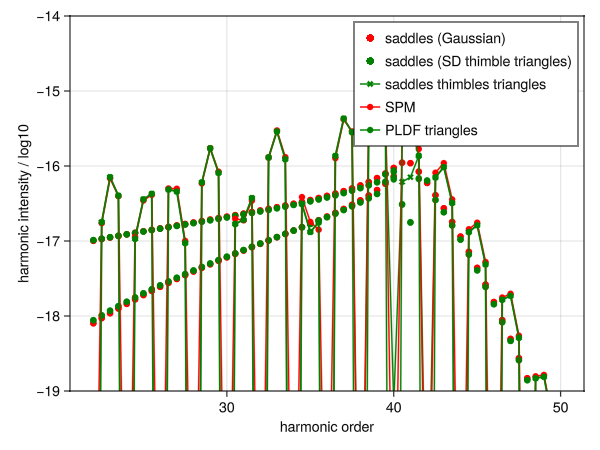

In [89]:
let
    fig= Figure()
    ax = Axis(fig[1,1], xlabel = "harmonic order", ylabel = "harmonic intensity / log10")
    
    f(dip, q) = log10(harmonic_intensity(beam_mono, dip, q))
  
    ### plot contributions from individual saddle points
    ### (can't draw them as line because there are different numbers of saddle points for each harmonic order and we haven't classified them)
    
    for (i, q) in enumerate(q_values)
        [scatter!(ax, [(q, f(s_dip,q))],
            label = "saddles (Gaussian)", color = :red) 
            for s_dip in dipoles_SPM[i]]
    
        [scatter!(ax, [(q, f(s_dip, q))],
            label = "saddles (SD thimble triangles)", color = :green)
            for s_dip in dipoles_triangles[i]]
        
#         [scatter!(ax, [(q, f(s_dip, q))],
#             label = "saddles (SD thimble quads)", color = :blue)
#             for s_dip in dipoles_quadrilaterals[i]]
        
    end
    
    ### sums over individual saddles' contributions    
    scatterlines!(ax,  [(q, f(dip, q)) for (q, dip) in zip(q_values, 
        [sum(q_dips) for q_dips in dipoles_triangles])],
        label = "saddles thimbles triangles",
        color= :green, marker=:x, linestyle= :solid)
    
#     scatterlines!(ax, [(q, f(dip, q)) for (q, dip) in zip(q_values, 
#         [sum(q_dips) for q_dips in dipoles_quadrilaterals])],
#         label = "saddles thimbles quads",
#         color= :blue, marker=:x, linestyle=:dash)

    ### plot the Gaussian SPM
    scatterlines!(ax, [(q, f(dip,q)) for (q,dip) in zip(q_values, total_dipoles_SPM)], label = "SPM", color= :red)
    
    ### from the full downward flow
    scatterlines!(ax, [(q, f(dip,q)) for (q,dip) in zip(q_values, total_dipoles_PLDF_triangles)],
        label = "PLDF triangles", color= :green)    
    
#     scatterlines!(ax, [(q, f(dip,q)) for (q,dip) in zip(q_values, total_dipoles_PLDF_quadrilaterals)],
#         label = "PLDF quadrilaterals", color= :blue)   

    
    ylims!(ax, -19, -14)
    
    axislegend(ax, merge=true)
    fig
end  

# dissecting the flowed thimble

After sufficiently many flow steps (`Nflow`), with big enough `flowstepfactor` etc., the flowed contour might break up into several disconnected parts. For the triangle-based downward flow we can "dissect" the full contour into those disconnected pieces, and treat (plot, integrate, ...???) them separately. 

~Note (09/06/2026):
Currently the integration of the thimbles constructed around the saddle points doesn't really work yet. I think this is because the orientation of the triangles isn't necessarily preserved in the necklace-like construction of the thimble. For the downward flow the orientation is preserved. That means using the downward flow and then integrating the dissected thimbles should give the correct result "per saddle point".~

Update (10/06/2026): the per-thimble integration from the saddle points works now <3

In [243]:
test_data = let
    beam = beam_mono
    q = 25.
    
    timin, timax = (0., 1.) .* TC
    ttmin, ttmax = (0.2, 1.) .* TC

    f, f_grad, f_hessian = action_functions(beam, Ip, q)
    init_points = make_init_points_parallelogram(timin, timax, ttmin, ttmax)
      
    triangles, points, simplices = get_flowed_triangles(f, f_grad, init_points,
        Nflow=20,
        flowstepfactor = 3.,
        subdividethreshold=8.,
        )
end;

I stopped because I reached the maximum flow steps, i.e. 20.


In [276]:
let
    q = 25.
    beam = beam_mono
    
    ### based on just the connectivities (=simplices, TriangleA) we can check whether there are disconnected components
    thimbles = dissect_thimbles(test_data[3])
    @show length(thimbles)
    
    ### for each of them, we can integrate
    for th in thimbles
        triangles = [TriangleC(test_data[2][sim.indices]) for sim in th]
        
        ### show the complex range for the selection of triangles (range of ti, range of tr) (gotta load the functions below)
        @show round.(span_2d_complex(triangles))
        
        ### calculate the integral
        int = sum([integrate_triangle_cheat(
            action_functions(beam, Ip, q)[1], tri,
            prefactor = (ti, tr) -> hhg_prefactor(beam, Ip, ti, tr),)
            for tri in triangles]) 
        @show int
        println()
    end
end

length(thimbles) = 3
round.(span_2d_complex(triangles)) = (ComplexDomain(5.0 + 18.0im, 79.0 + 56.0im), ComplexDomain(83.0 - 48.0im, 176.0 + 48.0im))
int = ComplexF64[-3.387141014765358e-6 - 9.257339042201714e-6im, 0.0 + 0.0im]

round.(span_2d_complex(triangles)) = (ComplexDomain(76.0 + 18.0im, 150.0 + 55.0im), ComplexDomain(154.0 - 48.0im, 247.0 + 48.0im))
int = ComplexF64[-3.3871410147683487e-6 - 9.257339042339332e-6im, 0.0 + 0.0im]

round.(span_2d_complex(triangles)) = (ComplexDomain(7.0 + 54.0im, 8.0 + 56.0im), ComplexDomain(30.0 + 12.0im, 39.0 + 16.0im))
int = ComplexF64[2.2734347038471136e-49 + 2.3459606486960295e-49im, 0.0 + 0.0im]



In [250]:
function span_2d_complex(points::Vector{PointA})
    tirmin, tirmax = extrema([real(p.x) for p in points])
    trrmin, trrmax = extrema([real(p.y) for p in points])
    tiimin, tiimax = extrema([imag(p.x) for p in points])
    trimin, trimax = extrema([imag(p.y) for p in points])    
    return ComplexDomain(tirmin+tiimin*im, tirmax+tiimax*im ), ComplexDomain(trrmin+trimin*im, trrmax+trimax*im )
end;

In [253]:
span_2d_complex(triangles::Vector{TriangleC}) = span_2d_complex(unique(vcat([sim.points for sim in triangles]...)))

span_2d_complex (generic function with 2 methods)

In [ ]:
import Base.round
round(cd::ComplexDomain; kwargs...) = ComplexDomain(Base.round(cd.min; kwargs...), Base.round(cd.max; kwargs...))